In [30]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf
import numpy as np

import jax
print(jax.devices())

[CudaDevice(id=0)]


## Constants

In [2]:
NUM_STEPS = 400
NUM_SAMPLES = 500
NUM_EPOCHS = 100
NUM_ITER_PER_EPOCH = 1000
BATCH_SIZE = 32

## Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    a = sup.transition.RandomWalk(
            bounds=(0.0, 4.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=0.0, scale=0.5)
        ),
    tau = sup.transition.RandomWalk(
            bounds=(0.0, 2.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=0,
            initial_prior=sup.prior.Prior(dist="normal", loc=-1.5, scale=0.5)
        ),
    bias = 0.5
)

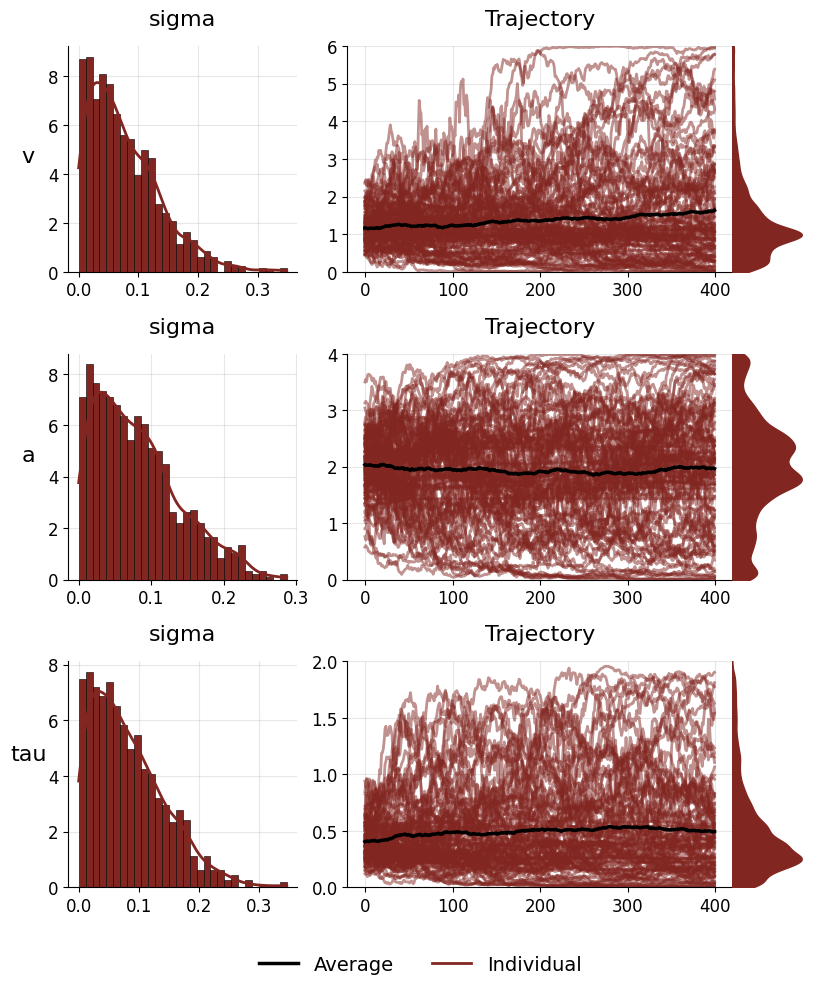

In [4]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_trajectories=100,
)

## Generative Model

In [5]:
ddm = sup.simulation.sample_ddm

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

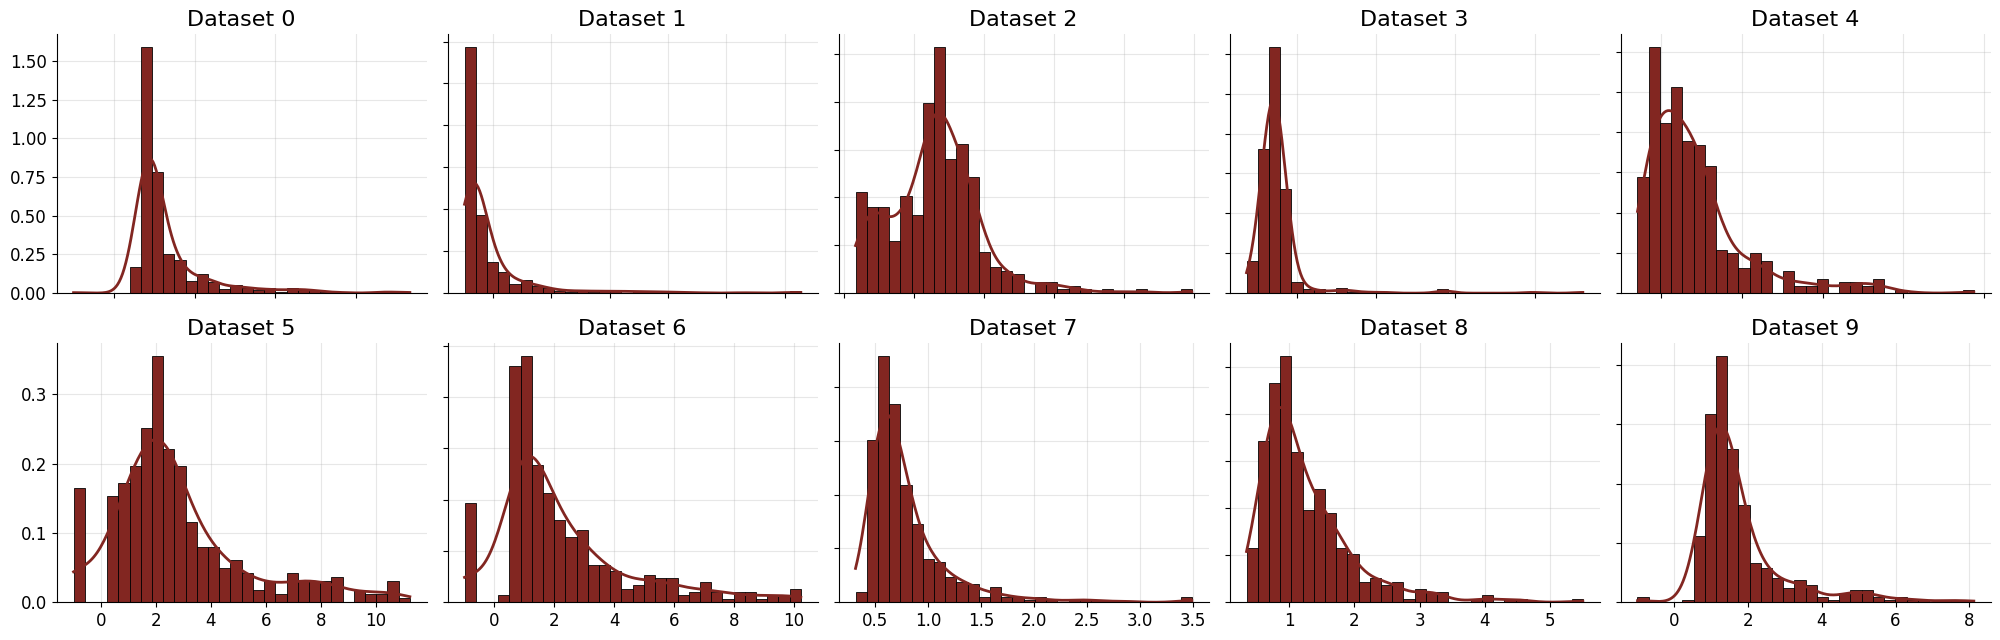

In [6]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    num_cols=5,
)

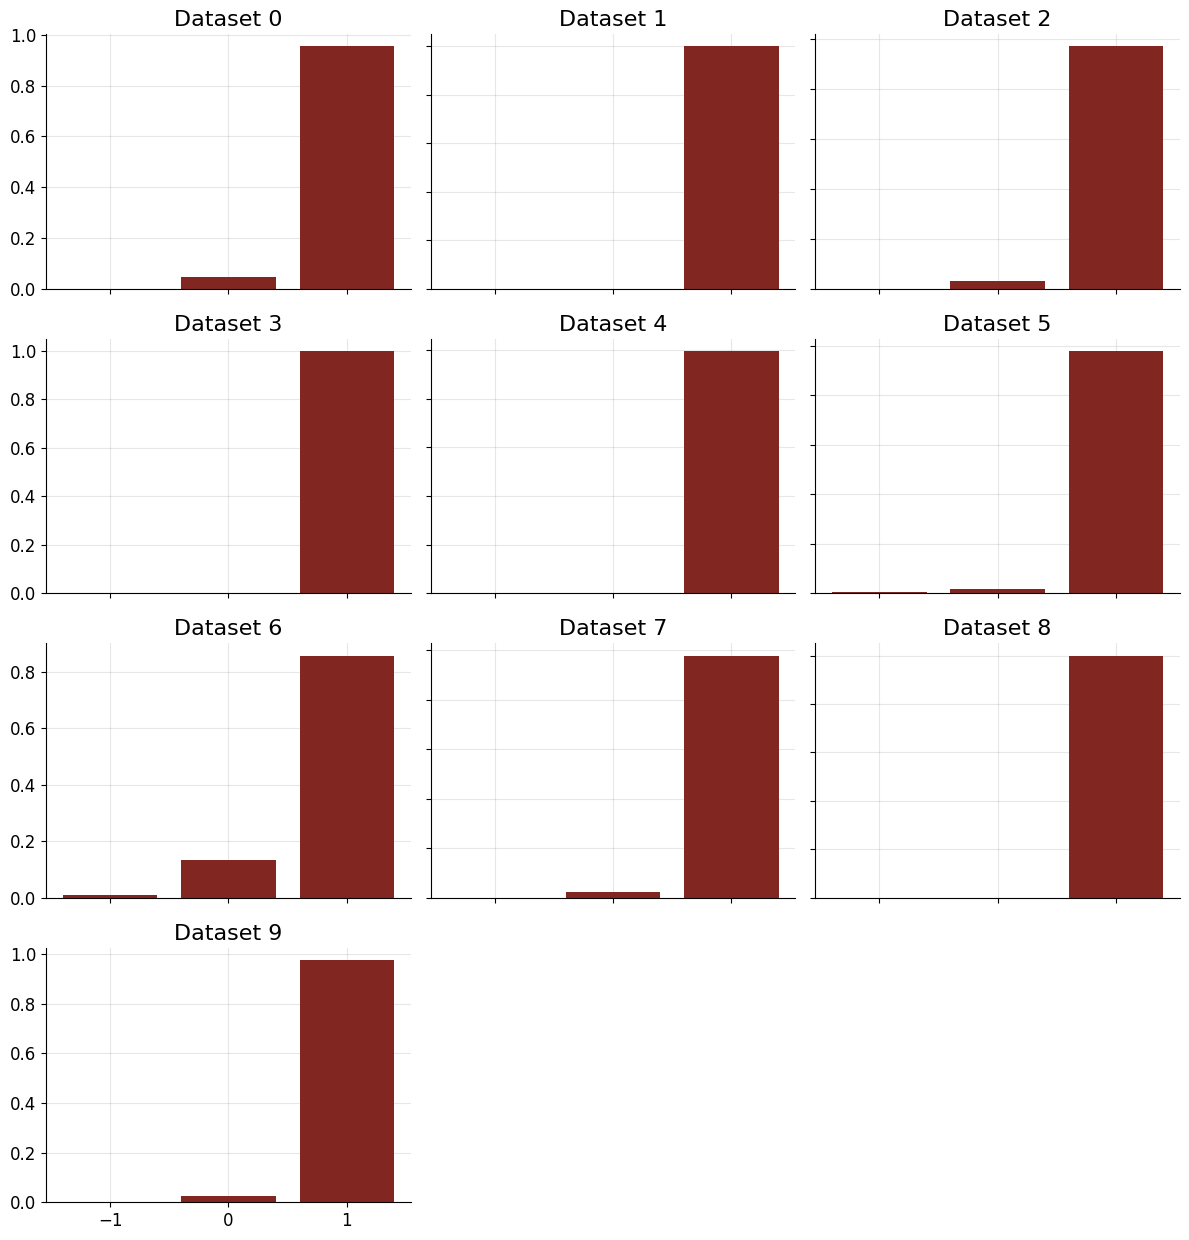

In [7]:
fig = generative_model.plot_push_forward(
    num_sim=10,
    num_steps=NUM_STEPS,
    data_dim=1,
    kind="dist",
)

## Workflow

In [8]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="ddm_benchmark"
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To restore the approximator from the checkpoint, call workflow.load_approximator() or pass restore=True to the workflow constructor.
INFO:bayesflow:Approximator restored from 'ddm_benchmark/model.keras'.


## Training

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=NUM_EPOCHS,
    num_batches_per_epoch=NUM_ITER_PER_EPOCH,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


Epoch 1/100
 161/1000 ━━━━━━━━━━━━━━━━━━━━ 7:52 563ms/step - loss: -2.8668

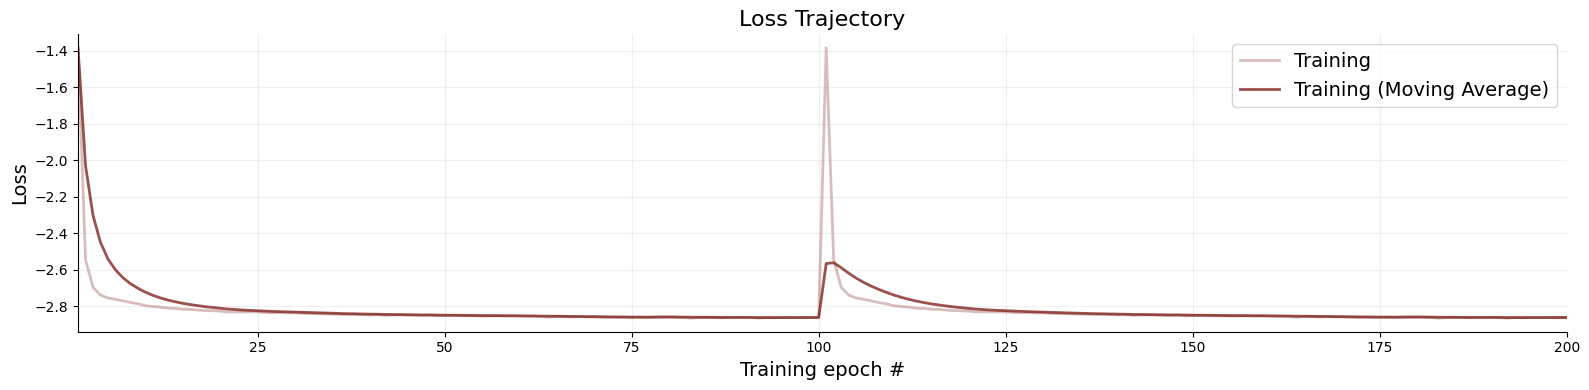

In [9]:
fig = workflow.plot_history(workflow.history)

## Verification

In [9]:
val_data = workflow.simulator.sample(
    batch_size=500,
    num_steps=NUM_STEPS
)

In [10]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=NUM_SAMPLES,
    inference_batch_size=1
)

Summarizing:   0%|          | 0/500 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/500 [00:00<?, ?batch/s]

### Time-varying Parameters

/scicore/home/rieskamp/schuma0018/GitHub/superstats/examples/../superstats/diagnostics/plots/time_varying_validation.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


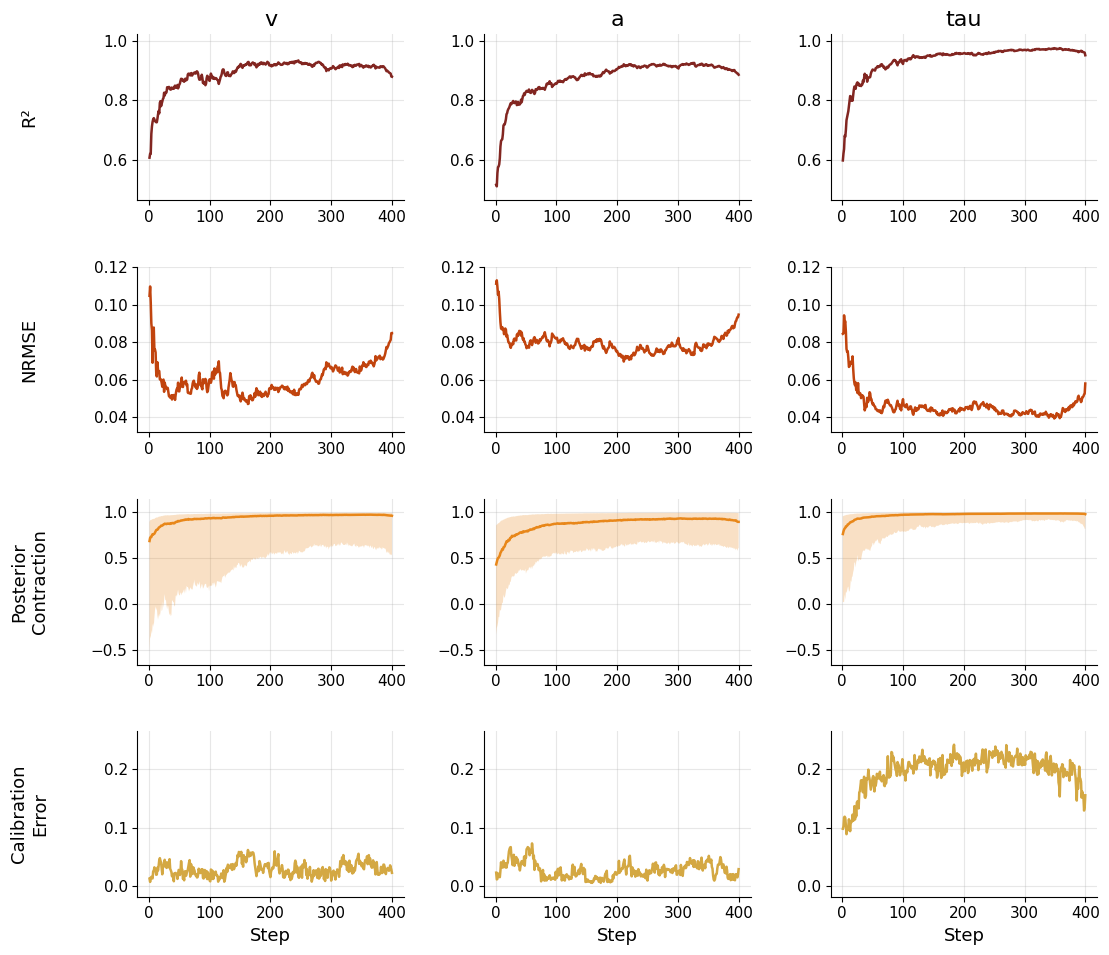

In [11]:
fig = workflow.validate_time_varying(val_data, samples)

In [42]:
time_step = 399
true = np.stack([val_data[k][:, time_step, 0] for k in local_keys], axis=-1)
estimates = np.stack([samples[k][:, :, time_step, 0] for k in local_keys], axis=-1)

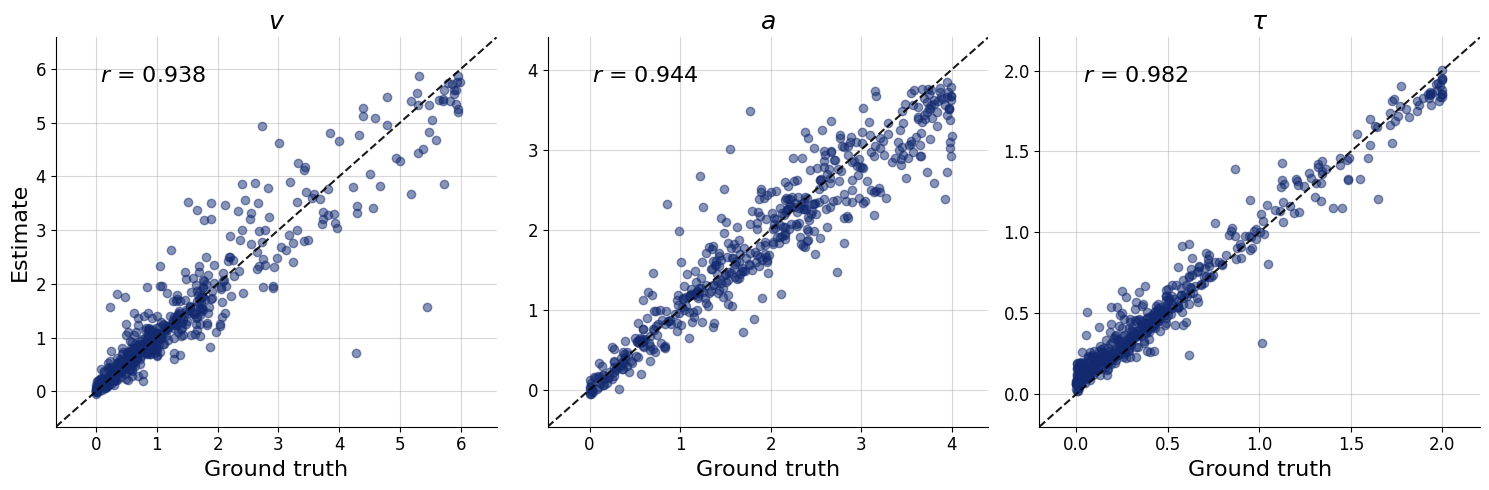

In [44]:
fig = bf.diagnostics.plots.recovery(
    estimates,
    true,
    variable_names = [r"$v$", r"$a$", r"$\tau$"],
    uncertainty_agg=None
)

### Time-invariant Parameters

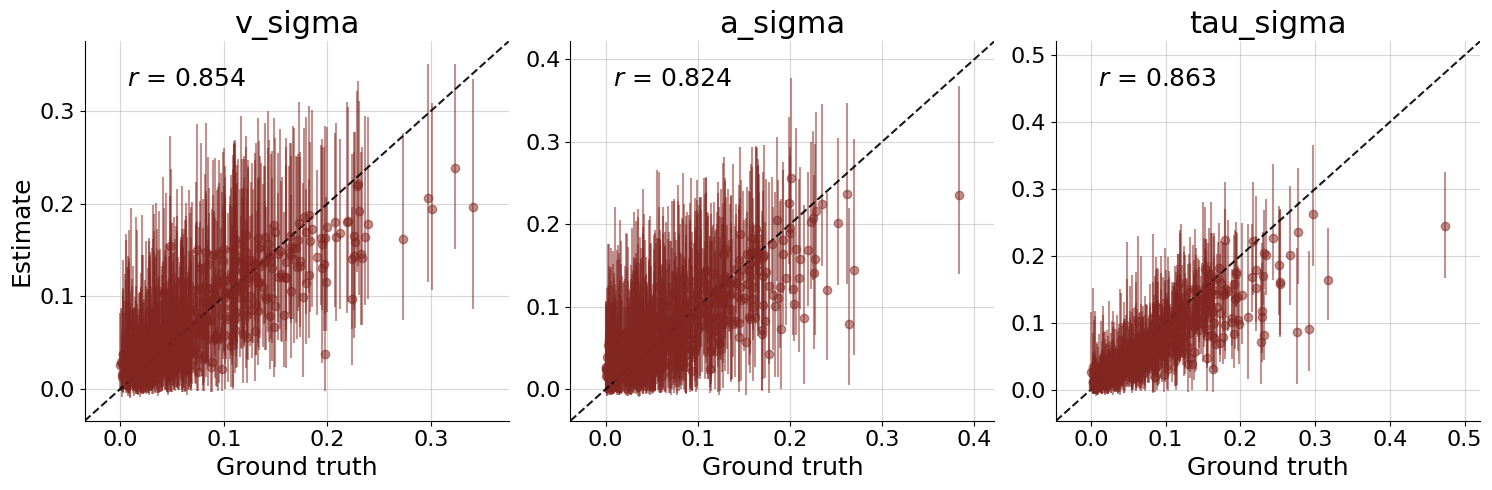

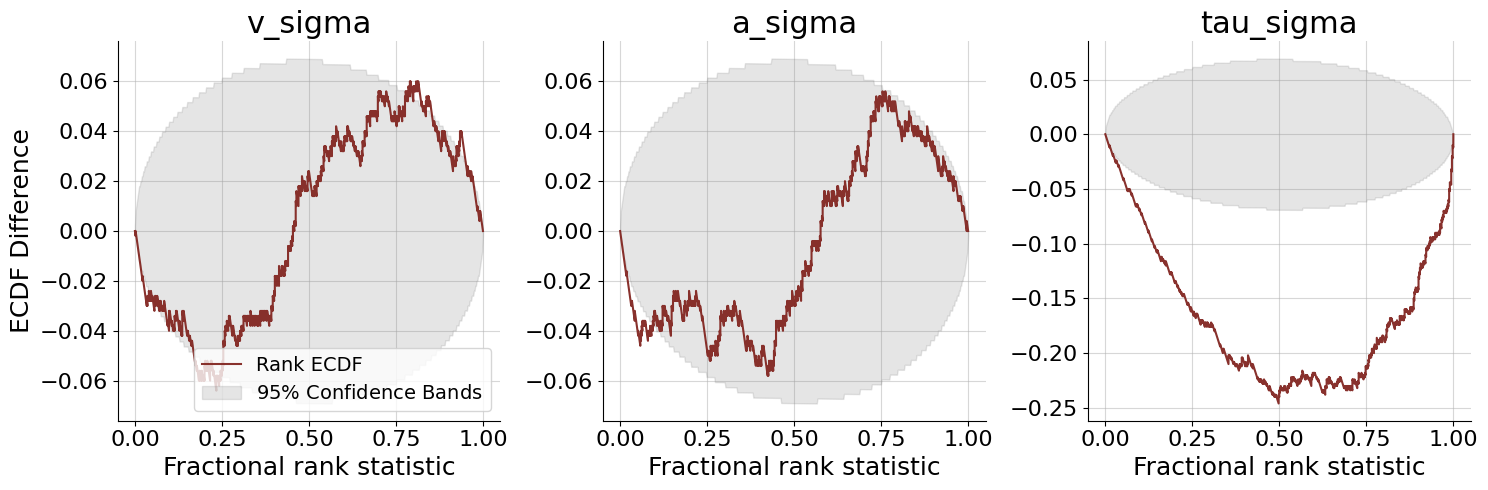

In [12]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    val_data,
    samples
)